Mark Batoon

DATA101

Professor Zare

A Clinical Perspective on U.S. Mortality Data: Drug Overdoses vs. Violent Crime (2019-2025)

I. Introduction

Understanding the intersection of public health and data is a crucial foundation for effective patient care and community nursing. The purpose of this analysis is to investigate the shifting landscape of fatal public health crises in the United States. Specifically, this project seeks to answer the following research question: How did the monthly rates of drug overdose deaths compare to other leading causes of violent mortality (such as firearm homicides and suicides) from 2019 to 2025? By examining these trends, healthcare professionals can better understand which epidemics are causing the most severe community harm and where to direct critical medical interventions.

To explore this question, this project utilizes the "Mapping Injury, Overdose, and Violence" dataset provided by the Centers for Disease Control and Prevention (CDC). This dataset is highly appropriate because it offers a comprehensive, national snapshot of mortality counts and rates categorized by specific causes of death over a multi-year timeline. This analysis focuses on several key columns: Period, which records the date of the data; Intent, which classifies the type of mortality, such as Drug_OD, FA_Homicide, or All_Suicide; and Rate, which standardizes the mortality figures per 100,000 population, allowing for accurate, scale-adjusted comparisons. The Type column is also used to filter the data exclusively to monthly records, ensuring accurate time-series tracking without double-counting.

II. Data Analysis

The overall analytical approach for this project involves an exploratory time-series analysis to evaluate shifts in mortality rates across different categories over a six-year period. To achieve this, several data wrangling techniques are utilized to prepare the raw dataset. First, the data is selected and filtered to isolate strictly monthly records, preventing any duplicate counting from overlapping yearly totals. Next, data cleaning is performed by dropping unnecessary columns—such as Data_As_Of and TTM_Date_Range—to streamline the dataset. Data transformation techniques are then applied to convert the Period column into functional datetime objects and ensure the Rate and Count columns are formatted appropriately as numeric values. Finally, grouping and aggregation methods are used to compile a summary table that calculates the average monthly deaths and rates for each mortality intent. This structured approach provides a clear numerical baseline to support the subsequent data visualizations and accurately interpret the results.

III. Conclusion and Future Directions

The analysis of the CDC data provides a clear and definitive answer to the research question: between 2019 and 2025, the national rate of drug overdose deaths vastly exceeded the mortality rates of both firearm homicides and suicides. The summary tables and visualizations reveal that while firearm-related deaths fluctuated within a lower, relatively stable range, drug overdose rates surged dramatically. Overdose rates peaked well above 30 deaths per 100,000 people before beginning to show signs of decline in 2024 and 2025. These findings are deeply meaningful in a clinical and community health context. They demonstrate that the public health burden of the overdose epidemic requires a massive, sustained allocation of emergency medical resources, addiction treatment facilities, and preventative patient care, often overshadowing the clinical volume of other violent injuries.

Building upon this work, future research should focus on merging this national dataset with state- or county-level demographic information to identify localized vulnerabilities. Analyzing how these mortality rates correlate with socioeconomic factors, or mapping them alongside the availability of local healthcare resources; such as mental health clinics and community outreach programs; would be highly beneficial. Understanding these localized trends is essential for directing targeted medical interventions and improving holistic, community-based care.


Reference

Centers for Disease Control and Prevention. (2025). Mapping Injury, Overdose, and Violence.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('CDC_MappingInjury_Overdose_Violence.csv')
df.head()

,GEOID,Intent,Period,Count,Rate,Type,Data_As_Of,TTM_Date_Range
0,USA,All_Homicide,01/01/2019,1574,5.6,month,02/11/2026,NaN
1,USA,All_Homicide,01/01/2019,19141,5.8,year,02/11/2026,NaN
2,USA,All_Suicide,01/01/2019,3833,13.7,month,02/11/2026,NaN
3,USA,All_Suicide,01/01/2019,47511,14.5,year,02/11/2026,NaN
4,USA,Drug_OD,01/01/2019,5095,18.3,month,02/11/2026,NaN


Specific Data Wrangling Techniques for this dataset
1. Selecting and filtering data
2. Data cleaning
3. Data transformation

In [17]:
#1 Selecting and Filtering data

df = df[df['Type'] == 'month']

#2 Data cleaning by dropping unnecessary columns)
df= df.drop(columns=['TTM_Date_Range', 'Data_As_Of', 'Type', 'GEOID'])

#3 Data Transformation
df['Period'] = pd.to_datetime(df['Period'])
df['Rate'] = pd.to_numeric(df['Rate'])
df['Count'] = pd.to_numeric(df['Count'])

df.head()

,Intent,Period,Count,Rate
0,All_Homicide,2019-01-01,1574,5.6
2,All_Suicide,2019-01-01,3833,13.7
4,Drug_OD,2019-01-01,5095,18.3
6,FA_Deaths,2019-01-01,3239,11.6
8,FA_Homicide,2019-01-01,1155,4.1


Summary Table

In [18]:
summary_table = df.groupby('Intent')[['Count', 'Rate']].mean().round(2)

summary_table.rename(columns={ 'Count': 'Average Monthly Deaths', 'Rate': 'Average Monthly Rate (per 100k)'}, inplace=True)

print("Table1: Average Monthly Deaths and Rates by Mortality Intent (2019-2025")
display(summary_table)

Table1: Average Monthly Deaths and Rates by Mortality Intent (2019-2025


,Average Monthly Deaths,Average Monthly Rate (per 100k)
Intent,,
All_Homicide,1858.49,6.71
All_Suicide,4026.96,14.52
Drug_OD,7235.19,26.09
FA_Deaths,3767.88,13.58
FA_Homicide,1450.28,5.23
FA_Suicide,2193.86,7.91


Data Visualization

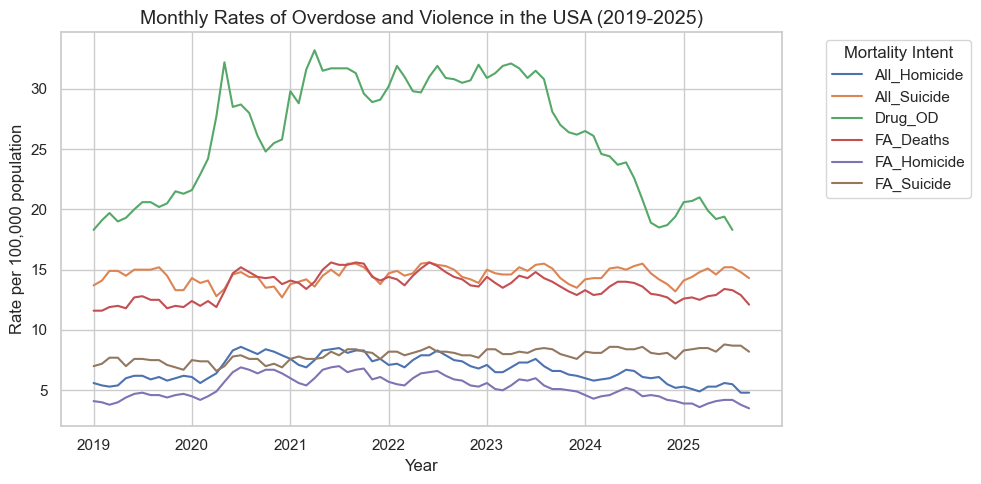

In [19]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

sns.lineplot(data=df, x='Period', y='Rate', hue='Intent')

plt.title('Monthly Rates of Overdose and Violence in the USA (2019-2025)', fontsize=14)
plt.ylabel('Rate per 100,000 population', fontsize=12)
plt.xlabel('Year', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Mortality Intent")

plt.tight_layout()
plt.show()